In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd

In [6]:
path = '/content/healthcare_dataset.csv'

In [9]:
df = pd.read_csv(path)

In [10]:
print("Shape:", df.shape)
display(df.head(5))

Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [11]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')

In [12]:
df.columns = df.columns.str.strip()


In [13]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [14]:
df['Test Results'] = pd.to_numeric(df['Test Results'], errors='coerce')

In [15]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,NaN
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,NaN
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,NaN
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,NaN
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,NaN


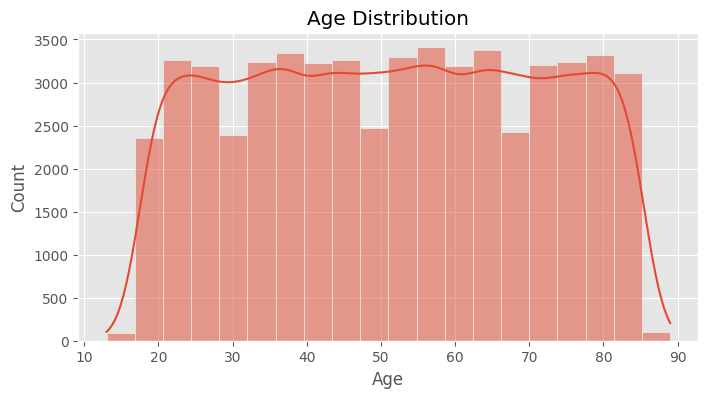

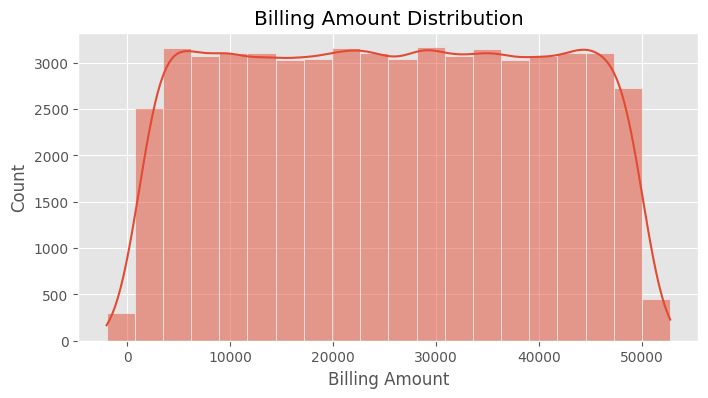

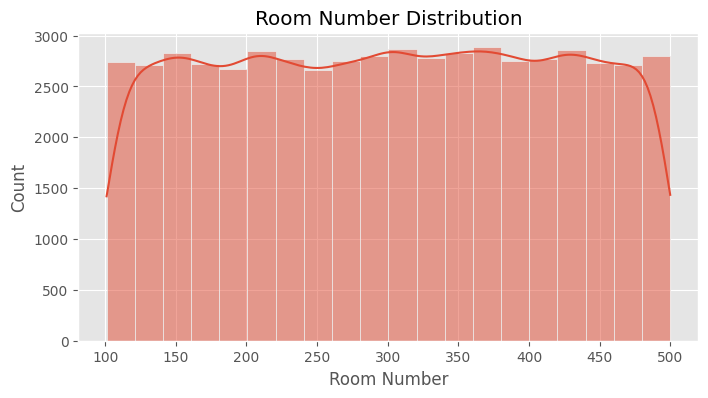

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8,4))
sns.histplot(df['Billing Amount'], bins=20, kde=True)
plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8,4))
sns.histplot(df['Room Number'], bins=20, kde=True)
plt.title("Room Number Distribution")
plt.xlabel("Room Number")
plt.ylabel("Count")
plt.show()


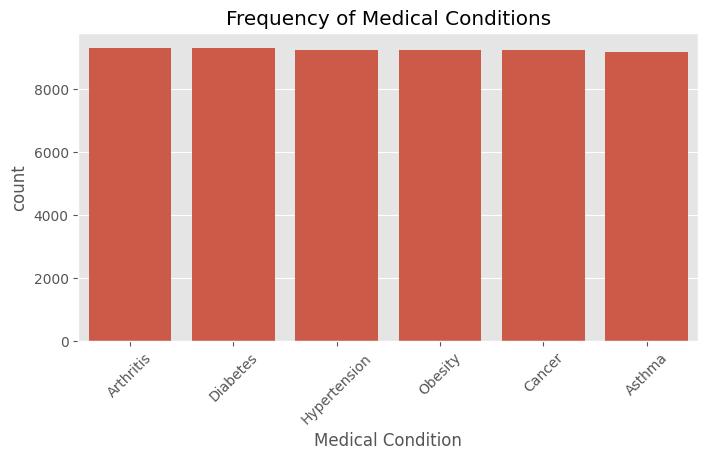

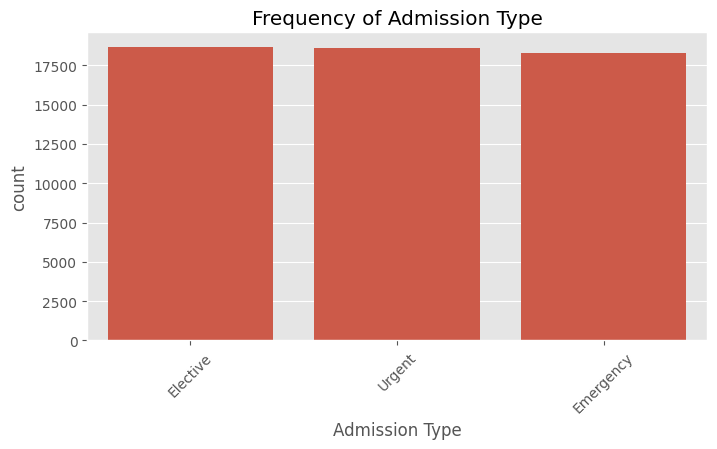

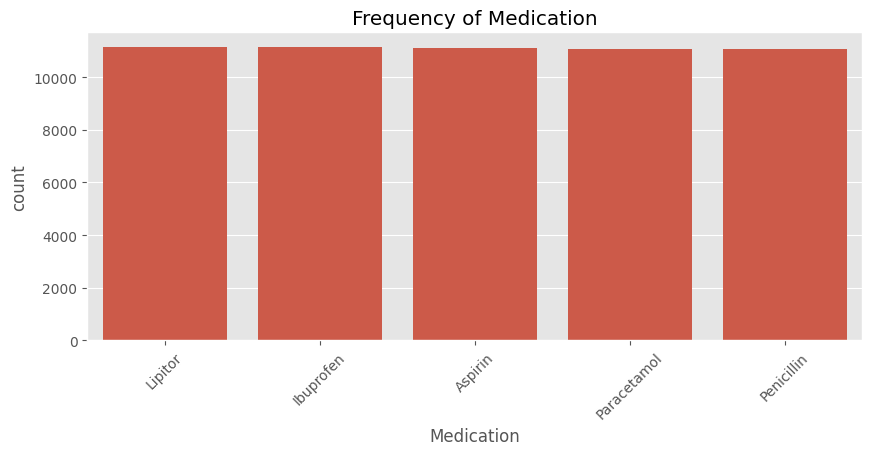

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Medical Condition', order=df['Medical Condition'].value_counts().index)
plt.title("Frequency of Medical Conditions")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Admission Type', order=df['Admission Type'].value_counts().index)
plt.title("Frequency of Admission Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Medication', order=df['Medication'].value_counts().index)
plt.title("Frequency of Medication")
plt.xticks(rotation=45)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_ml = df.copy()

label_encoders = {}

categorical_cols = ['Name', 'Gender', 'Blood Type', 'Medical Condition',
                    'Doctor', 'Hospital', 'Insurance Provider',
                    'Admission Type', 'Medication']

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

df_ml = df_ml.drop(columns=['Date of Admission', 'Discharge Date'])

X = df_ml.drop(columns=['Test Results'])
y = df_ml['Test Results']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((44400, 12), (11100, 12))

Total rows: 55500
Non-NaN Test Results: 0 (0.00%)
Not enough Test Results available — switching target to: Billing Amount
Dropped 0 rows with NaN target for 'Billing Amount'. Remaining rows: 55500
Feature matrix shape: (55500, 12)
Target vector shape: (55500,)
Train shape: (44400, 12) Test shape: (11100, 12)

Model Evaluation for target: Billing Amount
MAE: 11229.3760
RMSE: 13348.4410
R²: 0.1042


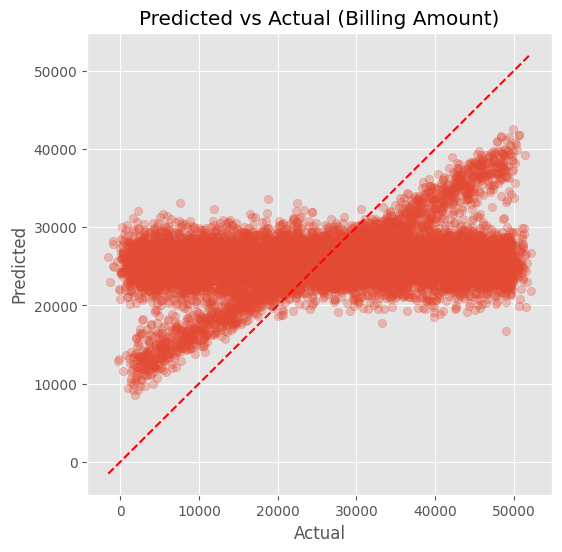


Saved model to: /content/drive/MyDrive/healthcare/models/rf_model_Billing_Amount.pkl
Saved label encoders to: /content/drive/MyDrive/healthcare/models/label_encoders.pkl


In [25]:
# Robust supervised-training cell: checks Test Results availability and falls back to Billing Amount if needed.
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the original df (not df_ml mutated earlier)
df_raw = df.copy()

# Ensure Test Results numeric (we did earlier, but check again)
df_raw['Test Results'] = pd.to_numeric(df_raw['Test Results'], errors='coerce')

total_rows = len(df_raw)
non_na_count = df_raw['Test Results'].notna().sum()
pct_non_na = non_na_count / total_rows

print(f"Total rows: {total_rows}")
print(f"Non-NaN Test Results: {non_na_count} ({pct_non_na:.2%})")

# Decision rule: require at least 1,000 non-NaN rows and >= 5% coverage to proceed with Test Results
use_test_results = (non_na_count >= 1000) and (pct_non_na >= 0.05)

if use_test_results:
    target_col = 'Test Results'
    print("Proceeding to predict: Test Results")
else:
    # fallback to Billing Amount (regression), which should be dense
    target_col = 'Billing Amount'
    print("Not enough Test Results available — switching target to:", target_col)

# Prepare df for ML: copy, encode and drop date columns
df_ml2 = df_raw.copy()

# Ensure Billing Amount numeric
if target_col == 'Billing Amount':
    df_ml2['Billing Amount'] = pd.to_numeric(df_ml2['Billing Amount'], errors='coerce')

# Simple preprocessing: drop rows with NaN in target
n_before = len(df_ml2)
df_ml2 = df_ml2.dropna(subset=[target_col]).copy()
n_after = len(df_ml2)
print(f"Dropped {n_before - n_after} rows with NaN target for '{target_col}'. Remaining rows: {n_after}")

# Label encode categorical columns (except the target)
categorical_cols = ['Name', 'Gender', 'Blood Type', 'Medical Condition',
                    'Doctor', 'Hospital', 'Insurance Provider',
                    'Admission Type', 'Medication']

label_encoders = {}
for col in categorical_cols:
    if col in df_ml2.columns:
        le = LabelEncoder()
        # Fill NaN temporarily if any
        df_ml2[col] = df_ml2[col].fillna('MISSING')
        df_ml2[col] = le.fit_transform(df_ml2[col].astype(str))
        label_encoders[col] = le

# Drop date columns
for dc in ['Date of Admission', 'Discharge Date']:
    if dc in df_ml2.columns:
        df_ml2 = df_ml2.drop(columns=[dc])

# Build X and y
X = df_ml2.drop(columns=[target_col])
y = df_ml2[target_col]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# If too few rows remain (e.g., < 200), warn and still try but results may be poor
if len(y) < 50:
    print("WARNING: Very few samples remain after cleaning (<50). Model may not be meaningful.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Train RandomForest
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation for target:", target_col)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
mmin = min(y_test.min(), y_pred.min())
mmax = max(y_test.max(), y_pred.max())
plt.plot([mmin, mmax], [mmin, mmax], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual ({target_col})")
plt.show()

# Save model and encoders
drive_dir = '/content/drive/MyDrive/healthcare/models'
os.makedirs(drive_dir, exist_ok=True)
model_name = f"rf_model_{target_col.replace(' ', '_')}.pkl"
encoders_name = "label_encoders.pkl"

model_path = os.path.join(drive_dir, model_name)
encoders_path = os.path.join(drive_dir, encoders_name)

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(encoders_path, 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nSaved model to:", model_path)
print("Saved label encoders to:", encoders_path)


In [27]:
def doctor_recommendation(age, condition, medication, predicted_bill):
    return f"""
AI Doctor Recommendation
------------------------
Patient Age: {age}
Medical Condition: {condition}
Current Medication: {medication}
Predicted Billing Amount: ${predicted_bill:,.2f}

Recommendation:
Based on the patient's medical condition and current medication,
the predicted billing amount appears consistent with moderate care intensity.

Advise the patient to continue their prescribed medication,
monitor symptoms regularly, and schedule a follow-up check within 2–4 weeks.

If any symptoms worsen — such as fatigue, abnormal blood sugar levels,
breathing difficulties, or unexpected side effects —
the patient should seek clinical attention immediately.

Lifestyle guidance:
- Maintain a balanced diet
- Increase daily physical activity gradually
- Ensure medication adherence
"""
sample = X_test.iloc[0]
sample_actual = y_test.iloc[0]
sample_pred = model.predict([sample])[0]

raw_index = sample.name
raw_row = df.iloc[raw_index]

age = raw_row['Age']
condition = raw_row['Medical Condition']
medication = raw_row['Medication']

recommendation_output = doctor_recommendation(age, condition, medication, sample_pred)
print(recommendation_output)



AI Doctor Recommendation
------------------------
Patient Age: 57
Medical Condition: Diabetes
Current Medication: Aspirin
Predicted Billing Amount: $29,403.14

Recommendation:
Based on the patient's medical condition and current medication,
the predicted billing amount appears consistent with moderate care intensity.

Advise the patient to continue their prescribed medication, 
monitor symptoms regularly, and schedule a follow-up check within 2–4 weeks.

If any symptoms worsen — such as fatigue, abnormal blood sugar levels, 
breathing difficulties, or unexpected side effects — 
the patient should seek clinical attention immediately.

Lifestyle guidance:
- Maintain a balanced diet
- Increase daily physical activity gradually
- Ensure medication adherence



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [28]:
clean_path = "/content/drive/MyDrive/healthcare-project/data/cleaned_healthcare.csv"
df_ml2.to_csv(clean_path, index=False)
print("Saved cleaned dataset to:", clean_path)


Saved cleaned dataset to: /content/drive/MyDrive/healthcare-project/data/cleaned_healthcare.csv


In [29]:
!cp "/content/drive/MyDrive/healthcare/models/rf_model_Billing_Amount.pkl" "/content/drive/MyDrive/healthcare-project/models/"
!cp "/content/drive/MyDrive/healthcare/models/label_encoders.pkl" "/content/drive/MyDrive/healthcare-project/models/"

print("Model and encoder files copied successfully!")


Model and encoder files copied successfully!
